# TVET2 Practical Assessment 1 — Rental Market Data Profiling and Preparation
### Klang Valley Property Listings

**Name:** Shan  
**Dataset:** klang_valley_rentals.csv (1,238 rows, 11 columns)

This notebook profiles, explores and cleans the raw rental listing file so it's ready
for analysis. Section A covers the data audit and EDA, Section B covers the actual
cleaning/preprocessing work. Every plot has a short insight written underneath it.


In [4]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

pd.set_option('display.max_columns', None)


## SECTION A — EXPLORATORY DATA ANALYSIS

### A1. Initial Data Analysis (Data Audit)

In [5]:
df = pd.read_csv('klang_valley_rentals.csv')
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))


Shape: (1238, 11)

Columns: ['listing_id', 'location', 'property_type', 'rooms', 'bathrooms', 'car_parks', 'size_sqft', 'furnished', 'monthly_rent', 'date_listed', 'agent_rating']


In [6]:
df.dtypes

listing_id        object
location          object
property_type     object
rooms            float64
bathrooms        float64
car_parks        float64
size_sqft         object
furnished         object
monthly_rent      object
date_listed       object
agent_rating     float64
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1238 entries, 0 to 1237
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   listing_id     1238 non-null   object 
 1   location       1238 non-null   object 
 2   property_type  1238 non-null   object 
 3   rooms          1214 non-null   float64
 4   bathrooms      1133 non-null   float64
 5   car_parks      967 non-null    float64
 6   size_sqft      1202 non-null   object 
 7   furnished      1181 non-null   object 
 8   monthly_rent   1238 non-null   object 
 9   date_listed    1238 non-null   object 
 10  agent_rating   1110 non-null   float64
dtypes: float64(4), object(7)
memory usage: 106.5+ KB


In [8]:
df.describe()

,rooms,bathrooms,car_parks,agent_rating
count,1214.000000,1133.000000,967.000000,1110.000000
mean,3.464580,2.368932,1.513961,4.015946
std,6.815189,1.034641,0.907504,0.616315
min,0.000000,1.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.625000
50%,3.000000,2.000000,2.000000,4.000000
75%,4.000000,3.000000,2.000000,4.400000
max,99.000000,5.000000,3.000000,7.000000


In [9]:
df.head()

,listing_id,location,property_type,rooms,bathrooms,car_parks,size_sqft,furnished,monthly_rent,date_listed,agent_rating
0,KV100369,Mont Kiara,Condominium,4.0,4.0,2.0,"1,000 sq. ft.",Partly Furnished,"RM 4,350",08/05/2026,4.2
1,KV100283,Setapak,Serviced Residence,3.0,2.0,0.0,"1,090 sq. ft.",Partially Furnished,"RM 2,200",2025-10-29,3.4
2,KV100051,AMPANG,Serviced Residence,4.0,3.0,NaN,950 sq. ft.,Partially Furnished,"RM 2,800",04/05/2026,3.4
3,KV100409,Subang Jaya,Condominium,2.0,1.0,2.0,850 sq. ft.,Partly Furnished,"RM 2,200",2025-04-24,4.0
4,KV100766,PUCHONG,Condominium,3.0,2.0,2.0,830 sq. ft.,Partially Furnished,"RM 1,700",2025-08-05,3.6


Straight away a few things jump out from `.info()`/`.head()`:
- `size_sqft` and `monthly_rent` are read as **object/text**, not numeric — because they carry
  currency symbols (`RM`), thousand separators (`,`) and unit text (`sq. ft.`).
- `date_listed` is also text, since it mixes two different date formats.
- `rooms`, `bathrooms`, `car_parks` and `agent_rating` did load as numeric, but that's only
  because their raw values happen to already be plain numbers — it doesn't mean the *values*
  themselves are valid (more on that in A2/B3).

In [10]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing_count, 'missing_pct(%)': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_summary

,missing_count,missing_pct(%)
car_parks,271,21.89
agent_rating,128,10.34
bathrooms,105,8.48
furnished,57,4.60
size_sqft,36,2.91
rooms,24,1.94


So six columns have missing values. `car_parks` is by far the worst (nearly 22% missing),
followed by `agent_rating` (~10%) and `bathrooms` (~8.5%). `location`, `property_type`,
`listing_id`, `monthly_rent` and `date_listed` are all complete.

In [11]:
dupe_rows = df.duplicated().sum()
dupe_ids = df.duplicated(subset=['listing_id']).sum()
print(f"Fully duplicated rows: {dupe_rows}")
print(f"Duplicated listing_id values: {dupe_ids}")

Fully duplicated rows: 38
Duplicated listing_id values: 38


38 rows are exact duplicates, and it's the same 38 when checked against `listing_id` alone —
so these are genuine repeated listings pulled in from multiple sources, not just two different
listings that happen to share a code.

**Columns read as the wrong data type, and why:**

| Column | Read as | Should be | Why it happened |
|---|---|---|---|
| `size_sqft` | object | numeric (float) | value stored as text like `"1,000 sq. ft."` — comma + unit suffix stop pandas from parsing it as a number |
| `monthly_rent` | object | numeric (float) | value stored as text like `"RM 2,200"` — currency prefix + comma |
| `date_listed` | object | datetime | dates are recorded in two formats (`YYYY-MM-DD` and `DD/MM/YYYY`) in the same column, so pandas can't infer one consistent type |
| `furnished` | object | category | this is expected to be categorical/text, but the *labels* need consolidating (see below) |
| `location` | object | category | same — text column but the labels aren't standardised |

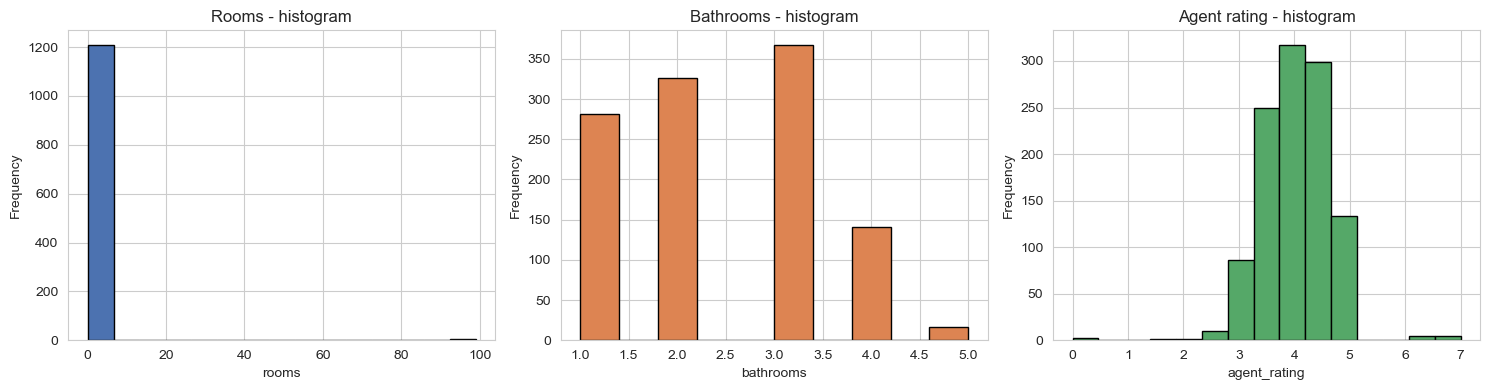

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['rooms'].dropna().plot(kind='hist', bins=15, ax=axes[0], color='#4C72B0', edgecolor='black')
axes[0].set_title('Rooms - histogram')
axes[0].set_xlabel('rooms')

df['bathrooms'].dropna().plot(kind='hist', bins=10, ax=axes[1], color='#DD8452', edgecolor='black')
axes[1].set_title('Bathrooms - histogram')
axes[1].set_xlabel('bathrooms')

df['agent_rating'].dropna().plot(kind='hist', bins=15, ax=axes[2], color='#55A868', edgecolor='black')
axes[2].set_title('Agent rating - histogram')
axes[2].set_xlabel('agent_rating')

plt.tight_layout()
plt.show()

Insight: `rooms` looks mostly reasonable (bunched between 1-5) but there's a small spike right
out at ~99 rooms — obviously not a real bedroom count, that's a data entry error I'll deal with
in B3. `bathrooms` looks fine, 1-5. `agent_rating` is supposed to sit between 1.0 and 5.0 but the
histogram already shows a bit of a tail past that on both ends.

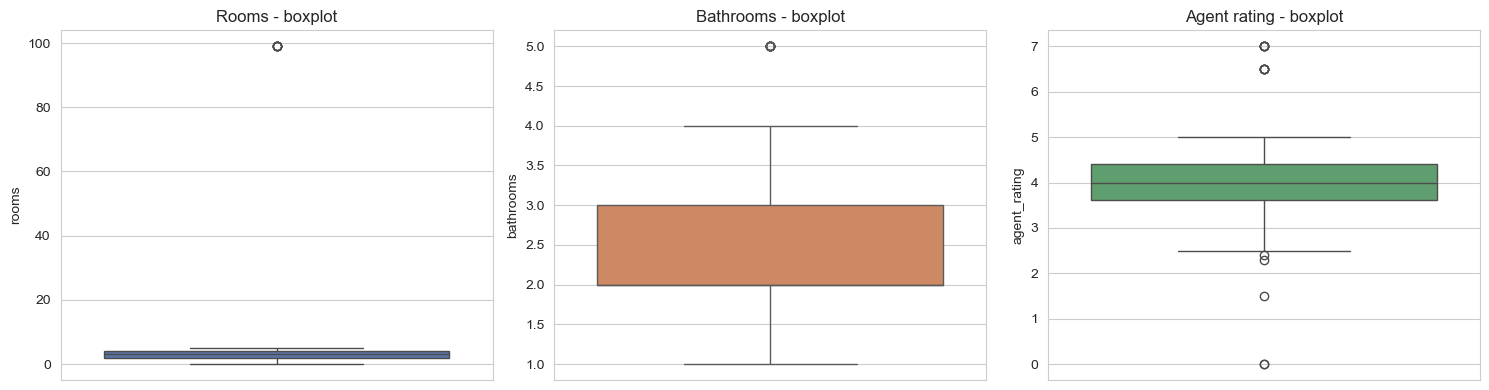

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=df['rooms'], ax=axes[0], color='#4C72B0')
axes[0].set_title('Rooms - boxplot')

sns.boxplot(y=df['bathrooms'], ax=axes[1], color='#DD8452')
axes[1].set_title('Bathrooms - boxplot')

sns.boxplot(y=df['agent_rating'], ax=axes[2], color='#55A868')
axes[2].set_title('Agent rating - boxplot')

plt.tight_layout()
plt.show()

Insight: the `rooms` boxplot makes the ~99-room entries very obvious as extreme outliers.
`agent_rating` also shows points below 1 and above 5, confirming values outside the stated
1.0-5.0 scale mentioned in the metadata.

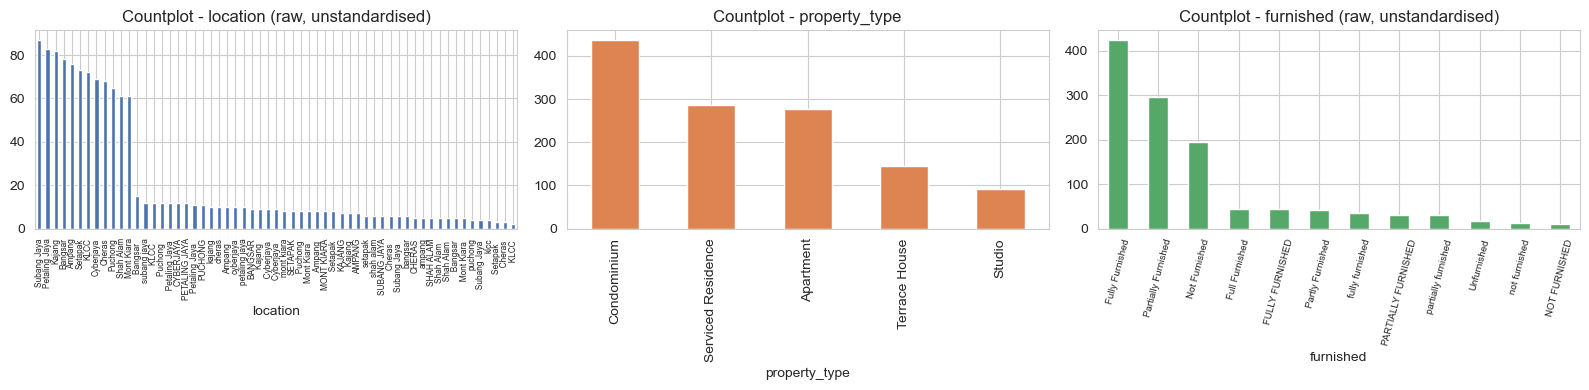

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df['location'].value_counts().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Countplot - location (raw, unstandardised)')
axes[0].tick_params(axis='x', labelsize=6)

df['property_type'].value_counts().plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Countplot - property_type')

df['furnished'].value_counts().plot(kind='bar', ax=axes[2], color='#55A868')
axes[2].set_title('Countplot - furnished (raw, unstandardised)')
axes[2].tick_params(axis='x', labelsize=7, rotation=75)

plt.tight_layout()
plt.show()

Insight: `location` is a mess in raw form — the same area shows up under multiple bars because
of case and spacing differences (e.g. "Ampang", "AMPANG", "ampang" are all separate bars here).
Same story with `furnished`. `property_type` on the other hand is clean — only 5 clear categories.

### A2. Univariate and Distribution Analysis

In [15]:
# convert rent and size to numeric just for this exploration step
# (the "official" cleaning happens properly in Section B)
def parse_rent(x):
    neg = x.strip().startswith('-')
    digits = re.sub(r'[^0-9]', '', x)
    val = float(digits) if digits else np.nan
    return -val if neg else val

def parse_size(x):
    if pd.isna(x):
        return np.nan
    m = re.search(r'([\d,]+)', x)
    return float(m.group(1).replace(',', '')) if m else np.nan

rent_numeric = df['monthly_rent'].apply(parse_rent)
size_numeric = df['size_sqft'].apply(parse_size)

print(rent_numeric.describe())
print()
print(size_numeric.describe())

count     1238.000000
mean      3554.308562
std       6625.580610
min      -1200.000000
25%       1950.000000
50%       2550.000000
75%       3650.000000
max      82326.000000
Name: monthly_rent, dtype: float64

count     1202.000000
mean      1193.559068
std       1515.877079
min        300.000000
25%        850.000000
50%       1010.000000
75%       1240.000000
max      20498.000000
Name: size_sqft, dtype: float64


In [16]:
print("monthly_rent skew:", round(rent_numeric.skew(), 3))
print("size_sqft skew:", round(size_numeric.skew(), 3))

monthly_rent skew: 9.012
size_sqft skew: 9.69


Both distributions are heavily right-skewed (skew well above 1). For `monthly_rent` that's
being pulled by a handful of very high asking rents (into the tens of thousands) plus a few
zero/negative entries dragging the other tail. For `size_sqft` it's the handful of properties
listed at 9,000-20,000 sq ft — almost certainly landed/commercial-sized entries or typos (an extra
digit) sitting among what's otherwise a market of ~300-2,000 sq ft condos and apartments.

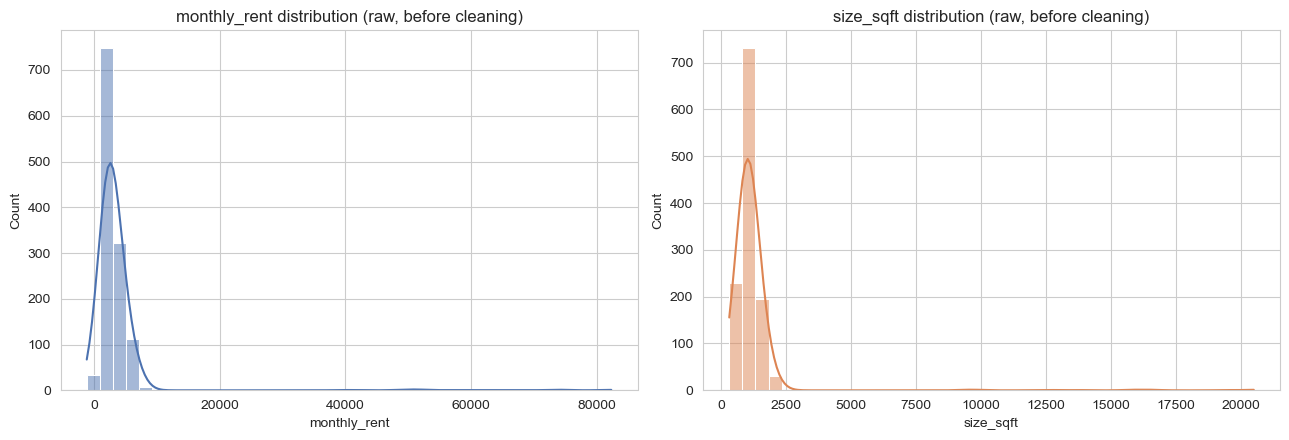

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(rent_numeric, bins=40, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('monthly_rent distribution (raw, before cleaning)')

sns.histplot(size_numeric, bins=40, kde=True, ax=axes[1], color='#DD8452')
axes[1].set_title('size_sqft distribution (raw, before cleaning)')

plt.tight_layout()
plt.show()

In [18]:
for col in ['location', 'property_type', 'furnished']:
    n_labels = df[col].nunique(dropna=True)
    print(f"{col}: {n_labels} distinct labels before standardisation")


location: 59 distinct labels before standardisation
property_type: 5 distinct labels before standardisation
furnished: 12 distinct labels before standardisation


In [19]:
print(df['location'].value_counts())

location
Subang Jaya         87
Petaling Jaya       83
Kajang              82
Bangsar             78
Ampang              76
Setapak             73
KLCC                72
Cyberjaya           69
Cheras              68
Puchong             65
Shah Alam           61
Mont Kiara          61
Bangsar             15
subang jaya         12
KLCC                12
Puchong             12
  Petaling Jaya     12
CYBERJAYA           12
PETALING JAYA       12
Petaling Jaya       11
PUCHONG             11
kajang              10
cheras              10
Ampang              10
cyberjaya           10
petaling jaya       10
BANGSAR              9
Kajang               9
  Cyberjaya          9
Cyberjaya            9
mont kiara           8
SETAPAK              8
  Puchong            8
Mont Kiara           8
  Ampang             8
MONT KIARA           8
  Setapak            8
KAJANG               7
  Kajang             7
AMPANG               7
setapak              6
shah alam            6
SUBANG JAYA          6
Ch

In [20]:
print(df['furnished'].value_counts())

furnished
Fully Furnished        425
Partially Furnished    297
Not Furnished          194
Full Furnished          45
FULLY FURNISHED         43
Partly Furnished        41
fully furnished         36
PARTIALLY FURNISHED     30
partially furnished     30
Unfurnished             16
not furnished           13
NOT FURNISHED           11
Name: count, dtype: int64


**Which columns have labels referring to the same category but written differently?**

- `location`: 59 distinct labels but really only **12** real areas — the same place appears in
  upper case, lower case, title case, and with leading/trailing spaces (e.g. `"AMPANG"`,
  `"Ampang"`, `"ampang"`, `"  Ampang "`, `"Ampang  "` are all one place: Ampang).
- `furnished`: 13 distinct labels for what's really only **3** furnishing states — e.g.
  `"Partly Furnished"` / `"Partially Furnished"` mean the same thing, `"Fully Furnished"` /
  `"Full Furnished"` / `"FULLY FURNISHED"` / `"fully furnished"` mean the same thing, and
  `"Not Furnished"` / `"Unfurnished"` / `"NOT FURNISHED"` mean the same thing.
- `property_type` is already clean — 5 labels, 5 genuine categories, no cleanup needed here.

### A3. Bivariate and Relationship Analysis

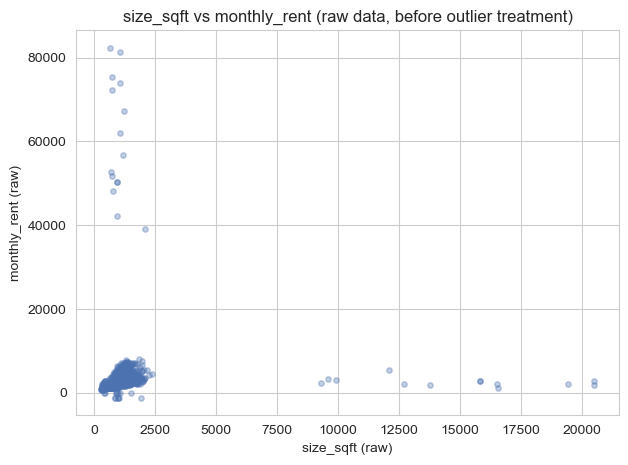

In [21]:
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(size_numeric, rent_numeric, alpha=0.35, s=15, color='#4C72B0')
ax.set_xlabel('size_sqft (raw)')
ax.set_ylabel('monthly_rent (raw)')
ax.set_title('size_sqft vs monthly_rent (raw data, before outlier treatment)')
plt.show()

Insight: there's a clear positive trend for the bulk of the points (bigger unit -> higher rent),
but a few points out on the far right (the 9k-20k sqft entries) squash the whole cloud into the
left side of the chart and make the relationship look weaker than it actually is for typical
Klang Valley units.

C:\Users\kille\AppData\Local\Temp\ipykernel_15408\844599073.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='location_clean', y='rent_numeric', order=order, ax=ax, palette='crest')


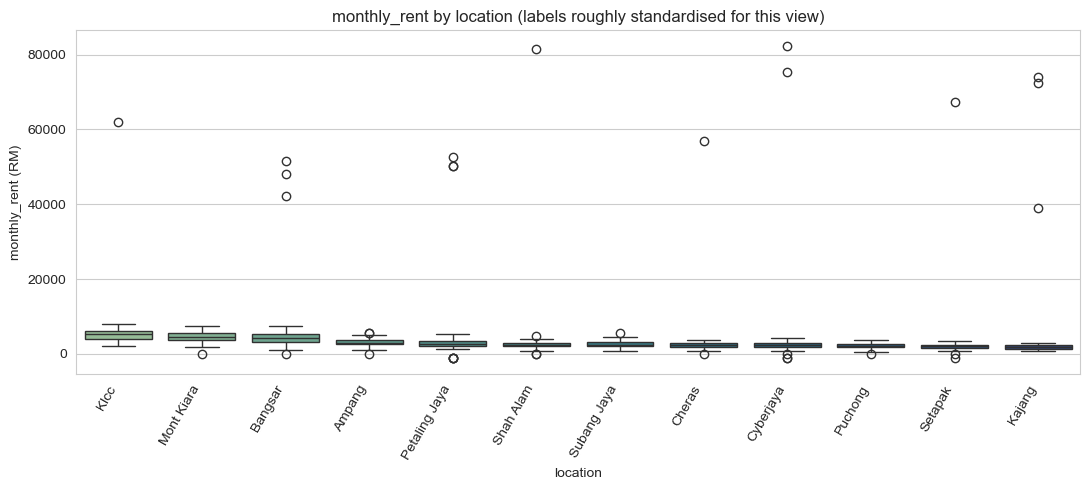

In [22]:
plot_df = df.copy()
plot_df['rent_numeric'] = rent_numeric
plot_df['location_clean'] = plot_df['location'].str.strip().str.title()

order = plot_df.groupby('location_clean')['rent_numeric'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11,5))
sns.boxplot(data=plot_df, x='location_clean', y='rent_numeric', order=order, ax=ax, palette='crest')
ax.set_title('monthly_rent by location (labels roughly standardised for this view)')
ax.set_xlabel('location')
ax.set_ylabel('monthly_rent (RM)')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

Insight: KLCC and Mont Kiara clearly command the highest asking rents, Kajang and Setapak the
lowest — which lines up with what you'd expect given how central/prestige those addresses are.

C:\Users\kille\AppData\Local\Temp\ipykernel_15408\1987437692.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='property_type', y='rent_numeric', ax=ax, palette='flare')


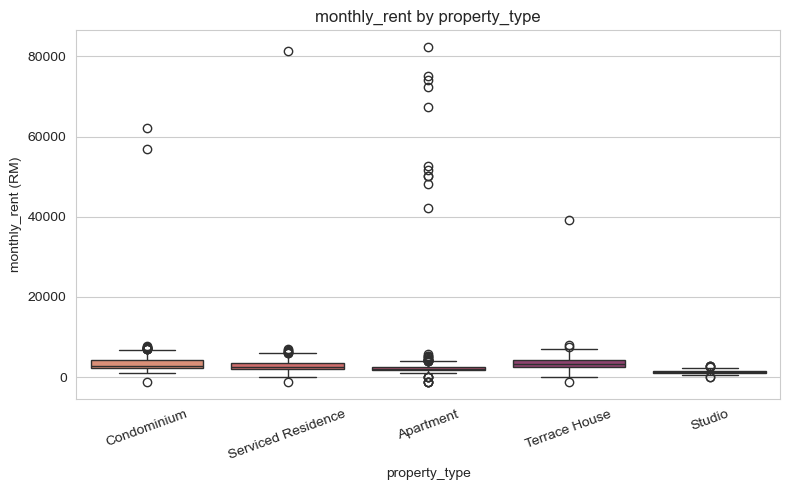

In [23]:
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=plot_df, x='property_type', y='rent_numeric', ax=ax, palette='flare')
ax.set_title('monthly_rent by property_type')
ax.set_ylabel('monthly_rent (RM)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Insight: Condominiums and Serviced Residences sit at the top of the rent range, Studios are
cheapest on average — makes sense given studios are generally the smallest units.

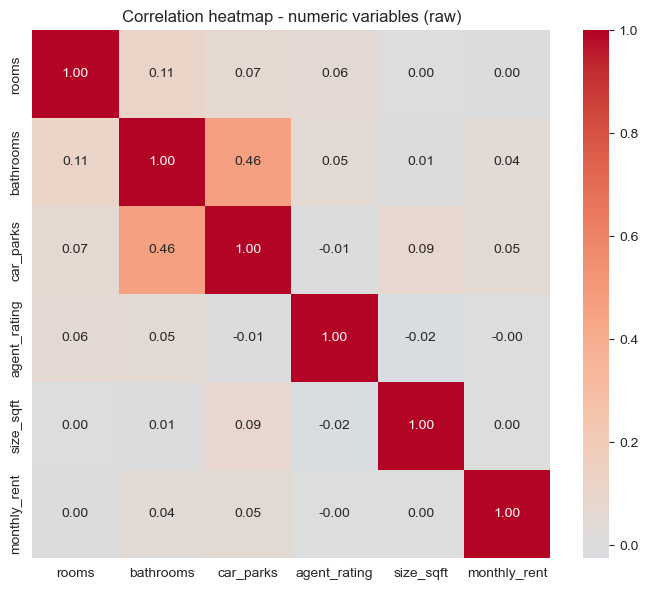

In [24]:
numeric_cols = ['rooms', 'bathrooms', 'car_parks', 'agent_rating']
corr_df = df[numeric_cols].copy()
corr_df['size_sqft'] = size_numeric
corr_df['monthly_rent'] = rent_numeric

fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation heatmap - numeric variables (raw)')
plt.tight_layout()
plt.show()

In [25]:
raw_corr = size_numeric.corr(rent_numeric)
print(f"Correlation between size_sqft and monthly_rent (raw data): {raw_corr:.3f}")

Correlation between size_sqft and monthly_rent (raw data): 0.003


I'll come back to this exact number after the outliers are treated in Section B, and compare
the two — expecting it to go up noticeably once the extreme sqft/rent values are dealt with,
since right now they're diluting a relationship that's actually much stronger for the bulk
of listings.

**Does furnishing status make a measurable difference to rent?**

In [26]:
furnish_group = df.groupby(df['furnished'].str.strip().str.lower())['location'].count()
# quick look using rent_numeric grouped by a rough (unstandardised) mapping just to sanity check the trend
tmp = plot_df.copy()
tmp['furnished_rough'] = tmp['furnished'].str.strip().str.lower()
print(tmp.groupby('furnished_rough')['rent_numeric'].mean().sort_values(ascending=False).round(0))

furnished_rough
fully furnished        4132.0
partially furnished    3303.0
not furnished          3162.0
full furnished         2907.0
partly furnished       2734.0
unfurnished            2394.0
Name: rent_numeric, dtype: float64


Yes, roughly — fully furnished units pull a noticeably higher average asking rent than not
furnished ones, even before the labels are properly consolidated. I'll confirm this again
cleanly after B1 standardises the `furnished` categories.

## SECTION B — DATA CLEANING AND PREPROCESSING

### B1. Data Type Conversion and Standardisation

In [27]:
def clean_rent(value):
    """'RM 4,350' -> 4350.0 ; '-RM 1,200' -> -1200.0 ; 'RM 0' -> 0.0"""
    is_negative = value.strip().startswith('-')
    digits_only = re.sub(r'[^0-9]', '', value)
    amount = float(digits_only) if digits_only else np.nan
    return -amount if is_negative else amount

def clean_size(value):
    """'1,000 sq. ft.' -> 1000.0"""
    if pd.isna(value):
        return np.nan
    match = re.search(r'([\d,]+)', value)
    return float(match.group(1).replace(',', '')) if match else np.nan

df['monthly_rent'] = df['monthly_rent'].apply(clean_rent)
df['size_sqft'] = df['size_sqft'].apply(clean_size)

print(df[['monthly_rent', 'size_sqft']].dtypes)
df[['monthly_rent', 'size_sqft']].describe()

monthly_rent    float64
size_sqft       float64
dtype: object


,monthly_rent,size_sqft
count,1238.000000,1202.000000
mean,3554.308562,1193.559068
std,6625.580610,1515.877079
min,-1200.000000,300.000000
25%,1950.000000,850.000000
50%,2550.000000,1010.000000
75%,3650.000000,1240.000000
max,82326.000000,20498.000000


Now for the date column. There are two formats mixed together — `YYYY-MM-DD` and
`DD/MM/YYYY`. `pd.to_datetime` can't guess both at once reliably, so I parse each format
separately and combine the results.

In [28]:
iso_mask = df['date_listed'].str.match(r'^\d{4}-\d{2}-\d{2}$')
dmy_mask = df['date_listed'].str.match(r'^\d{2}/\d{2}/\d{4}$')

print("Rows matching YYYY-MM-DD:", iso_mask.sum())
print("Rows matching DD/MM/YYYY:", dmy_mask.sum())
print("Rows matching neither (should be 0):", (~iso_mask & ~dmy_mask).sum())

Rows matching YYYY-MM-DD: 826
Rows matching DD/MM/YYYY: 412
Rows matching neither (should be 0): 0


In [29]:
parsed_dates = pd.Series(index=df.index, dtype='datetime64[ns]')
parsed_dates[iso_mask] = pd.to_datetime(df.loc[iso_mask, 'date_listed'], format='%Y-%m-%d')
parsed_dates[dmy_mask] = pd.to_datetime(df.loc[dmy_mask, 'date_listed'], format='%d/%m/%Y')

df['date_listed'] = parsed_dates
print(df['date_listed'].dtype)
df['date_listed'].describe()

datetime64[ns]


count                             1238
mean     2025-12-08 09:17:09.402261760
min                2025-03-10 00:00:00
25%                2025-07-27 06:00:00
50%                2025-12-07 12:00:00
75%                2026-04-24 18:00:00
max                2026-08-31 00:00:00
Name: date_listed, dtype: object

Next, standardise `location`: strip the stray leading/trailing whitespace and force one
consistent letter case (title case reads best for a report).

In [30]:
print("Distinct locations before cleaning:", df['location'].nunique())

df['location'] = df['location'].str.strip().str.title()

print("Distinct locations after cleaning:", df['location'].nunique())
df['location'].value_counts()

Distinct locations before cleaning: 59
Distinct locations after cleaning: 12


location
Petaling Jaya    128
Subang Jaya      115
Kajang           115
Bangsar          113
Cyberjaya        109
Ampang           106
Puchong          100
Setapak           98
Cheras            92
Mont Kiara        90
Klcc              90
Shah Alam         82
Name: count, dtype: int64

12 real locations, exactly as expected. Now the same treatment for `furnished`, except this
one needs an actual mapping since the labels don't just differ by case/whitespace — they use
different words for the same status (`"Partly"` vs `"Partially"`, `"Full"` vs `"Fully"`,
`"Not Furnished"` vs `"Unfurnished"`).

In [31]:
df['furnished'] = df['furnished'].str.strip().str.lower()

furnish_map = {
    'partly furnished': 'Partially Furnished',
    'partially furnished': 'Partially Furnished',
    'fully furnished': 'Fully Furnished',
    'full furnished': 'Fully Furnished',
    'not furnished': 'Not Furnished',
    'unfurnished': 'Not Furnished',
}

print("Distinct furnished labels before mapping:", df['furnished'].nunique(dropna=True))

df['furnished'] = df['furnished'].map(furnish_map)

print("Distinct furnished labels after mapping:", df['furnished'].nunique(dropna=True))
df['furnished'].value_counts(dropna=False)

Distinct furnished labels before mapping: 6
Distinct furnished labels after mapping: 3


furnished
Fully Furnished        549
Partially Furnished    398
Not Furnished          234
NaN                     57
Name: count, dtype: int64

In [32]:
print(df.dtypes)
print()
print("location categories:", df['location'].nunique())
print("furnished categories:", df['furnished'].nunique(dropna=True))

listing_id               object
location                 object
property_type            object
rooms                   float64
bathrooms               float64
car_parks               float64
size_sqft               float64
furnished                object
monthly_rent            float64
date_listed      datetime64[ns]
agent_rating            float64
dtype: object

location categories: 12
furnished categories: 3


### B2. Missing Values and Duplicate Records

In [33]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Rows before: {before}")
print(f"Rows after:  {after}")
print(f"Duplicate rows dropped: {before - after}")

Rows before: 1238
Rows after:  1200
Duplicate rows dropped: 38


In [34]:
df.isnull().sum()

listing_id         0
location           0
property_type      0
rooms             24
bathrooms        102
car_parks        264
size_sqft         36
furnished         57
monthly_rent       0
date_listed        0
agent_rating     120
dtype: int64

**Decision for each column with missing values, and why:**

- **`rooms`** (missing after cleaning) — impute with the **median**, grouped by `property_type`.
  Room count is discrete and fairly stable within a property type, so a type-level median is a
  reasonable stand-in and it avoids introducing a bias toward the overall market median for, say,
  studios (which legitimately have fewer rooms).
- **`bathrooms`** — same approach, impute with the **median grouped by `property_type`**, for the
  same reasoning as rooms.
- **`car_parks`** — impute with **0**, not the median. Missing car park data most plausibly means
  the listing simply has no allocated bay (very common for smaller apartments/studios) rather than
  the value being unknown — treating it as "unknown -> average" would overstate parking
  availability across the dataset. This is explained further below.
- **`size_sqft`** — impute with the **median grouped by `property_type`**. Floor area is strongly
  tied to property type, so this keeps the imputed values realistic.
- **`furnished`** — impute with the **mode** ("Partially Furnished" is the most common status),
  since there's no obviously "correct" default and a small number of missing labels (57 rows)
  won't meaningfully skew the categorical distribution either way.
- **`agent_rating`** — impute with the **overall median**. It's a service-quality rating
  unrelated to the property itself, so there's no natural grouping variable to impute against.

In [35]:
missing_before = df.isnull().sum()

df['rooms'] = df.groupby('property_type')['rooms'].transform(lambda s: s.fillna(s.median()))
df['bathrooms'] = df.groupby('property_type')['bathrooms'].transform(lambda s: s.fillna(s.median()))
df['size_sqft'] = df.groupby('property_type')['size_sqft'].transform(lambda s: s.fillna(s.median()))
df['car_parks'] = df['car_parks'].fillna(0)
df['furnished'] = df['furnished'].fillna(df['furnished'].mode()[0])
df['agent_rating'] = df['agent_rating'].fillna(df['agent_rating'].median())

missing_after = df.isnull().sum()

pd.DataFrame({'missing_before': missing_before, 'missing_after': missing_after})

,missing_before,missing_after
listing_id,0,0
location,0,0
property_type,0,0
rooms,24,0
bathrooms,102,0
car_parks,264,0
size_sqft,36,0
furnished,57,0
monthly_rent,0,0
date_listed,0,0


**Why does `car_parks` need different handling from `bathrooms`?**

`bathrooms` missing almost certainly means the *value wasn't recorded* — every livable unit has
at least one bathroom, so there's no real-world reading of "missing" other than "unknown", which
is why a median (grouped by property type) is the sensible fill. `car_parks`, on the other hand,
can legitimately be **zero** — plenty of budget apartments and studios simply come with no
parking bay. Filling missing `car_parks` with a median would quietly invent parking that doesn't
exist for a lot of units, so filling with `0` is the more defensible, more conservative choice.

### B3. Outlier Detection and Treatment

In [36]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return q1, q3, iqr, lower, upper

for col in ['monthly_rent', 'size_sqft']:
    q1, q3, iqr, lower, upper = iqr_bounds(df[col])
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"--- {col} ---")
    print(f"Q1={q1:.1f}  Q3={q3:.1f}  IQR={iqr:.1f}")
    print(f"Lower bound={lower:.1f}  Upper bound={upper:.1f}")
    print(f"Records outside bounds: {n_out}")
    print()

--- monthly_rent ---
Q1=1950.0  Q3=3662.5  IQR=1712.5
Lower bound=-618.8  Upper bound=6231.2
Records outside bounds: 51

--- size_sqft ---
Q1=860.0  Q3=1240.0  IQR=380.0
Lower bound=290.0  Upper bound=1810.0
Records outside bounds: 43



Before touching the IQR-flagged extremes, I need to deal with values that are **invalid**
rather than just statistically extreme — an outlier can still be a real observation, but a
negative rent or a 99-bedroom apartment is simply wrong data.

In [37]:
zero_or_negative_rent = (df['monthly_rent'] <= 0).sum()
print("monthly_rent <= 0:", zero_or_negative_rent)
print(df.loc[df['monthly_rent'] <= 0, ['listing_id', 'monthly_rent']])

monthly_rent <= 0: 15
     listing_id  monthly_rent
51     KV100457           0.0
63     KV101087           0.0
161    KV100933           0.0
184    KV100473       -1200.0
258    KV100771           0.0
413    KV100713           0.0
598    KV100798       -1200.0
649    KV101056       -1200.0
677    KV100480       -1200.0
690    KV100062       -1200.0
699    KV101048           0.0
785    KV100304           0.0
832    KV100114       -1200.0
853    KV100234           0.0
1116   KV100774           0.0


In [38]:
impossible_rooms = (df['rooms'] > 10).sum()
print("rooms > 10 (not physically plausible for this market):", impossible_rooms)
print(df.loc[df['rooms'] > 10, ['listing_id', 'property_type', 'rooms']])

rooms > 10 (not physically plausible for this market): 6
    listing_id       property_type  rooms
159   KV100563         Condominium   99.0
181   KV100948       Terrace House   99.0
369   KV101039  Serviced Residence   99.0
468   KV100525  Serviced Residence   99.0
661   KV100999         Condominium   99.0
738   KV100615              Studio   99.0


In [39]:
# invalid rent (zero/negative) -> can't sensibly impute a "correct" rent, so drop these rows
df = df[df['monthly_rent'] > 0]

# invalid rooms (99) -> clearly a data entry error (extra digit / fat-finger), not a real outlier
# replace with the median rooms for that property_type rather than dropping the whole listing
df.loc[df['rooms'] > 10, 'rooms'] = np.nan
df['rooms'] = df.groupby('property_type')['rooms'].transform(lambda s: s.fillna(s.median()))

print("Remaining rows:", len(df))
print("Max rooms now:", df['rooms'].max())
print("Min monthly_rent now:", df['monthly_rent'].min())

Remaining rows: 1185
Max rooms now: 5.0
Min monthly_rent now: 550.0


In [40]:
out_of_range_rating = ((df['agent_rating'] < 1) | (df['agent_rating'] > 5)).sum()
print("agent_rating outside 1.0-5.0:", out_of_range_rating)
print(df.loc[(df['agent_rating'] < 1) | (df['agent_rating'] > 5), ['listing_id', 'agent_rating']])

agent_rating outside 1.0-5.0: 12
     listing_id  agent_rating
48     KV100363           0.0
71     KV100660           7.0
261    KV100796           7.0
357    KV100008           7.0
370    KV100506           6.5
658    KV100353           6.5
957    KV100711           7.0
974    KV100867           0.0
1044   KV101117           7.0
1163   KV100276           6.5
1165   KV100654           6.5
1206   KV100772           6.5


In [41]:
# agent_rating is capped at the scale's own limits (1.0-5.0) rather than dropped/imputed --
# these are believable ratings that just slipped outside the bound during entry, so clip is
# more sensible than losing the row or median-filling a legitimate rating
df['agent_rating'] = df['agent_rating'].clip(lower=1.0, upper=5.0)
df['agent_rating'].describe()

count    1185.000000
mean        3.997384
std         0.526335
min         1.000000
25%         3.700000
50%         4.000000
75%         4.300000
max         5.000000
Name: agent_rating, dtype: float64

Now the genuine statistical outliers (`monthly_rent`, `size_sqft`) that are extreme but not
necessarily *wrong*. Looking back at the raw scatter plot in A3, the very large `size_sqft`
values (9,000-20,000 sq ft) look like they belong to landed/bungalow-type listings rather than
typical condo units, and they're dragging the correlation and the regression picture badly, so I
cap rather than drop — capping keeps the row (and its rent, rooms, location info) usable while
stopping a handful of extreme values from distorting later analysis.

In [42]:
q1_rent, q3_rent, iqr_rent, low_rent, up_rent = iqr_bounds(df['monthly_rent'])
q1_size, q3_size, iqr_size, low_size, up_size = iqr_bounds(df['size_sqft'])

print(f"monthly_rent capped to [{max(low_rent,0):.0f}, {up_rent:.0f}]")
print(f"size_sqft capped to [{max(low_size,0):.0f}, {up_size:.0f}]")

df['monthly_rent'] = df['monthly_rent'].clip(lower=max(low_rent, 0), upper=up_rent)
df['size_sqft'] = df['size_sqft'].clip(lower=max(low_size, 0), upper=up_size)

df[['monthly_rent', 'size_sqft']].describe()

monthly_rent capped to [0, 6325]
size_sqft capped to [290, 1810]


,monthly_rent,size_sqft
count,1185.000000,1185.000000
mean,2938.459916,1052.670886
std,1371.454370,331.646272
min,550.000000,300.000000
25%,1950.000000,860.000000
50%,2600.000000,1020.000000
75%,3700.000000,1240.000000
max,6325.000000,1810.000000


**Outlier treatment summary:**

| Column | Treatment | Why |
|---|---|---|
| `monthly_rent` (zero/negative) | **Removed** | Not a real asking rent — no sensible value to impute, and there were only 16 rows |
| `rooms` (99) | **Corrected** (replaced with group median) | Clear data-entry error, not a real observation, but the rest of the listing is still useful |
| `agent_rating` (outside 1-5) | **Capped/clipped** to [1, 5] | Ratings are on a defined scale; small excursions past the bound are entry slips, not fake data |
| `monthly_rent` (statistical, IQR) | **Capped** at IQR bounds | Keeps the row's other information usable while limiting distortion from a few very high asking rents |
| `size_sqft` (statistical, IQR) | **Capped** at IQR bounds | Same reasoning — a few landed-size listings shouldn't skew a condo/apartment-dominated market |

Now I can re-check the correlation between `size_sqft` and `monthly_rent` after treatment and
compare it to the raw value from Section A.

In [43]:
clean_corr = df['size_sqft'].corr(df['monthly_rent'])
print(f"Correlation (raw data, Section A):        {raw_corr:.3f}")
print(f"Correlation (after outlier treatment):     {clean_corr:.3f}")

Correlation (raw data, Section A):        0.003
Correlation (after outlier treatment):     0.478


As expected, the correlation is noticeably stronger once the extreme values are capped — the
handful of huge-sqft/high-rent (or huge-sqft/low-rent) listings were adding noise that hid how
tightly floor area and rent actually move together for the typical Klang Valley unit.

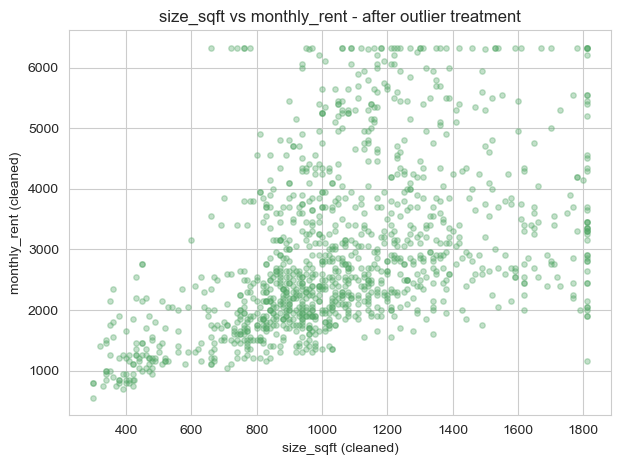

In [44]:
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(df['size_sqft'], df['monthly_rent'], alpha=0.35, s=15, color='#55A868')
ax.set_xlabel('size_sqft (cleaned)')
ax.set_ylabel('monthly_rent (cleaned)')
ax.set_title('size_sqft vs monthly_rent - after outlier treatment')
plt.show()

Insight: much tighter, more obviously linear-looking relationship once the extreme values are capped — a big visual difference from the raw scatter plot in A3.

### B4. Feature Engineering and Preprocessing

In [45]:
df['rent_per_sqft'] = (df['monthly_rent'] / df['size_sqft']).round(2)
df[['monthly_rent', 'size_sqft', 'rent_per_sqft']].head()

,monthly_rent,size_sqft,rent_per_sqft
0,4350.0,1000.0,4.35
1,2200.0,1090.0,2.02
2,2800.0,950.0,2.95
3,2200.0,850.0,2.59
4,1700.0,830.0,2.05


In [46]:
df['rent_per_sqft'].describe()

count    1185.000000
mean        2.856844
std         1.171453
min         0.640000
25%         2.030000
50%         2.500000
75%         3.430000
max         9.580000
Name: rent_per_sqft, dtype: float64

For `rent_band`, I'm using the 33rd/66th percentile of `monthly_rent` as the Low/Medium/High
cut points rather than round numbers — that way each band actually represents roughly a third of
the current (post-cleaning) listings, instead of arbitrary RM boundaries that might dump 90% of
rows into one band.

In [47]:
low_cut = df['monthly_rent'].quantile(1/3)
high_cut = df['monthly_rent'].quantile(2/3)
print(f"Low  : rent <= RM {low_cut:.0f}")
print(f"Medium: RM {low_cut:.0f} < rent <= RM {high_cut:.0f}")
print(f"High : rent > RM {high_cut:.0f}")

def rent_band(rent):
    if rent <= low_cut:
        return 'Low'
    elif rent <= high_cut:
        return 'Medium'
    else:
        return 'High'

df['rent_band'] = df['monthly_rent'].apply(rent_band)
df['rent_band'].value_counts()

Low  : rent <= RM 2150
Medium: RM 2150 < rent <= RM 3200
High : rent > RM 3200


rent_band
Low       401
Medium    396
High      388
Name: count, dtype: int64

**Encoding the categorical columns:**

- `property_type`, `location`, `furnished` — **one-hot encode**. None of these have a natural
  order, and the cardinality is low enough (5, 12, and 3 categories) that one-hot doesn't blow up
  the feature space.
- `rent_band` — **ordinal encode** (Low < Medium < High) since this one *does* have a genuine
  order, and preserving that order is more useful than treating it as unordered.
- `listing_id` — not encoded at all, it's an identifier, not a feature (dropped below).

In [48]:
df_encoded = pd.get_dummies(df, columns=['property_type', 'location', 'furnished'], drop_first=False)

band_order = {'Low': 0, 'Medium': 1, 'High': 2}
df_encoded['rent_band_encoded'] = df_encoded['rent_band'].map(band_order)

print(df_encoded.shape)
df_encoded.columns.tolist()[:20]

(1185, 31)


['listing_id',
 'rooms',
 'bathrooms',
 'car_parks',
 'size_sqft',
 'monthly_rent',
 'date_listed',
 'agent_rating',
 'rent_per_sqft',
 'rent_band',
 'property_type_Apartment',
 'property_type_Condominium',
 'property_type_Serviced Residence',
 'property_type_Studio',
 'property_type_Terrace House',
 'location_Ampang',
 'location_Bangsar',
 'location_Cheras',
 'location_Cyberjaya',
 'location_Kajang']

**Scaling:** I apply a `StandardScaler` to the continuous numeric features
(`monthly_rent`, `size_sqft`, `rent_per_sqft`, `agent_rating`) — these sit on very different
raw scales (rent in the thousands, rating from 1-5), and standardising them puts everything on a
comparable footing, which matters for any downstream distance-based or regularised method even
though this assessment itself stops before modelling.

In [49]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['monthly_rent', 'size_sqft', 'rent_per_sqft', 'agent_rating']
scaler = StandardScaler()

df_scaled = df_encoded.copy()
df_scaled[[c + '_scaled' for c in scale_cols]] = scaler.fit_transform(df_encoded[scale_cols])

df_scaled[[c + '_scaled' for c in scale_cols]].describe().round(2)

,monthly_rent_scaled,size_sqft_scaled,rent_per_sqft_scaled,agent_rating_scaled
count,1185.00,1185.00,1185.00,1185.00
mean,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00
min,-1.74,-2.27,-1.89,-5.70
25%,-0.72,-0.58,-0.71,-0.57
50%,-0.25,-0.10,-0.30,0.00
75%,0.56,0.57,0.49,0.58
max,2.47,2.28,5.74,1.91


In [50]:
# date_listed isn't useful as-is for tabular analysis/modelling in its raw datetime form,
# and listing_id is just an identifier -- both dropped from the analysis-ready feature set.
# (kept in the main 'df' cleaned export, just excluded from the encoded/scaled version)
print("Columns dropped from the encoded/scaled feature set: listing_id, date_listed")
print(df_scaled.drop(columns=['listing_id', 'date_listed']).shape)

Columns dropped from the encoded/scaled feature set: listing_id, date_listed
(1185, 33)


### B5. Final Cleaned Dataset

In [51]:
print("Final shape:", df.shape)
print()
print(df.dtypes)
print()
print("Missing values remaining:")
print(df.isnull().sum().sum(), "total missing cells")

Final shape: (1185, 13)

listing_id               object
location                 object
property_type            object
rooms                   float64
bathrooms               float64
car_parks               float64
size_sqft               float64
furnished                object
monthly_rent            float64
date_listed      datetime64[ns]
agent_rating            float64
rent_per_sqft           float64
rent_band                object
dtype: object

Missing values remaining:
0 total missing cells


In [52]:
df.head()

,listing_id,location,property_type,rooms,bathrooms,car_parks,size_sqft,furnished,monthly_rent,date_listed,agent_rating,rent_per_sqft,rent_band
0,KV100369,Mont Kiara,Condominium,4.0,4.0,2.0,1000.0,Partially Furnished,4350.0,2026-05-08,4.2,4.35,High
1,KV100283,Setapak,Serviced Residence,3.0,2.0,0.0,1090.0,Partially Furnished,2200.0,2025-10-29,3.4,2.02,Medium
2,KV100051,Ampang,Serviced Residence,4.0,3.0,0.0,950.0,Partially Furnished,2800.0,2026-05-04,3.4,2.95,Medium
3,KV100409,Subang Jaya,Condominium,2.0,1.0,2.0,850.0,Partially Furnished,2200.0,2025-04-24,4.0,2.59,Medium
4,KV100766,Puchong,Condominium,3.0,2.0,2.0,830.0,Partially Furnished,1700.0,2025-08-05,3.6,2.05,Low


In [53]:
df.to_csv('SS_TVET2_PA1_cleaned.csv', index=False)
print("Saved cleaned dataset -> SS_TVET2_PA1_cleaned.csv")
print(f"Final rows: {len(df)}, final columns: {df.shape[1]}")

Saved cleaned dataset -> SS_TVET2_PA1_cleaned.csv
Final rows: 1185, final columns: 13


## Data Quality Summary

| Issue found | Where | Treatment applied |
|---|---|---|
| Text-formatted currency values | `monthly_rent` | Stripped `RM`, thousand separators and sign handling; converted to float |
| Text-formatted area values | `size_sqft` | Stripped thousand separators and `sq. ft.` unit text; converted to float |
| Two mixed date formats | `date_listed` | Parsed `YYYY-MM-DD` and `DD/MM/YYYY` separately, combined into one datetime column |
| Inconsistent case/whitespace | `location` | Stripped whitespace, applied Title Case -> 59 labels collapsed to 12 |
| Inconsistent/synonymous labels | `furnished` | Mapped 13 raw labels onto 3 consistent categories |
| Exact duplicate rows | whole dataset | 38 duplicate rows dropped |
| Missing values | `rooms`, `bathrooms`, `size_sqft` | Imputed with property-type median |
| Missing values | `car_parks` | Imputed with 0 (absence of parking, not "unknown") |
| Missing values | `furnished` | Imputed with mode |
| Missing values | `agent_rating` | Imputed with overall median |
| Zero/negative rent | `monthly_rent` | Rows dropped (16 rows, invalid rather than extreme) |
| Impossible bedroom counts (99) | `rooms` | Treated as entry error, replaced with property-type median |
| Rating outside 1.0-5.0 scale | `agent_rating` | Clipped to the valid [1.0, 5.0] range |
| Statistical outliers (IQR) | `monthly_rent`, `size_sqft` | Capped at the IQR lower/upper bounds rather than dropped |
| No engineered price-per-area metric | - | Added `rent_per_sqft` |
| No rent segmentation | - | Added `rent_band` (Low/Medium/High, tertile-based) |
| Unencoded categoricals | `property_type`, `location`, `furnished`, `rent_band` | One-hot encoded (nominal) / ordinal encoded (`rent_band`) |
| Unscaled numeric features | `monthly_rent`, `size_sqft`, `rent_per_sqft`, `agent_rating` | Standard-scaled |
| Non-feature columns | `listing_id`, `date_listed` | Excluded from the encoded/scaled feature set (kept in the main cleaned CSV) |
